<a href="https://colab.research.google.com/github/Vishal106-Cse/vishal/blob/main/Restaurant_Analytics_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('zomato.csv', on_bad_lines='skip', engine='python')

# Display the first 5 rows and data info
print("--- First 5 Rows ---")
display(df.head())

print("\n--- Data Structure & Missing Values ---")
df.info()

--- First 5 Rows ---


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari



--- Data Structure & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31799 entries, 0 to 31798
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          31799 non-null  object
 1   address                      31799 non-null  object
 2   name                         31799 non-null  object
 3   online_order                 31799 non-null  object
 4   book_table                   31799 non-null  object
 5   rate                         26964 non-null  object
 6   votes                        31799 non-null  int64 
 7   phone                        31138 non-null  object
 8   location                     31788 non-null  object
 9   rest_type                    31656 non-null  object
 10  dish_liked                   14164 non-null  object
 11  cuisines                     31773 non-null  object
 12  approx_cost(for two people)  31648 non-null  ob

In [3]:
# 1. Drop columns we don't need for basic analytics
# 'url' and 'address' take up a lot of memory and aren't useful for numerical trends.
df_cleaned = df.drop(columns=['url', 'address'])

# 2. Clean the 'rate' column
# It currently has strings like '4.1/5'. We need to extract just '4.1' as a number.
def clean_rate(value):
    if pd.isna(value) or value == 'NEW' or value == '-':
        return np.nan
    value = str(value).split('/')[0].strip()
    return float(value)

df_cleaned['rate'] = df_cleaned['rate'].apply(clean_rate)

# 3. Clean 'approx_cost(for two people)' column if it exists
# Let's find the exact name of the cost column and remove commas
cost_col = [col for col in df_cleaned.columns if 'cost' in col.lower()]
if cost_col:
    col_name = cost_col[0]
    df_cleaned[col_name] = df_cleaned[col_name].astype(str).str.replace(',', '')
    df_cleaned[col_name] = pd.to_numeric(df_cleaned[col_name], errors='coerce')
    df_cleaned.rename(columns={col_name: 'approx_cost_two'}, inplace=True)

# Look at our clean dataset summary
print("--- Cleaned Data Info ---")
df_cleaned.info()
print("\n--- Quick Statistical Summary ---")
display(df_cleaned.describe())


--- Cleaned Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31799 entries, 0 to 31798
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             31799 non-null  object 
 1   online_order     31799 non-null  object 
 2   book_table       31799 non-null  object 
 3   rate             25320 non-null  float64
 4   votes            31799 non-null  int64  
 5   phone            31138 non-null  object 
 6   location         31788 non-null  object 
 7   rest_type        31656 non-null  object 
 8   dish_liked       14164 non-null  object 
 9   cuisines         31773 non-null  object 
 10  approx_cost_two  31648 non-null  float64
 11  reviews_list     31799 non-null  object 
 12  menu_item        31799 non-null  object 
 13  listed_in(type)  31799 non-null  object 
 14  listed_in(city)  31799 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 3.6+ MB

--- Quick Statistic

,rate,votes,approx_cost_two
count,25320.000000,31799.000000,31648.000000
mean,3.687595,249.977232,527.958070
std,0.430666,694.504560,398.517884
min,1.800000,0.000000,40.000000
25%,3.400000,6.000000,300.000000
50%,3.700000,39.000000,400.000000
75%,4.000000,183.000000,600.000000
max,4.900000,16345.000000,6000.000000


/tmp/ipykernel_9241/3462674182.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='online_order', y='rate', data=df_cleaned, palette='Set2')


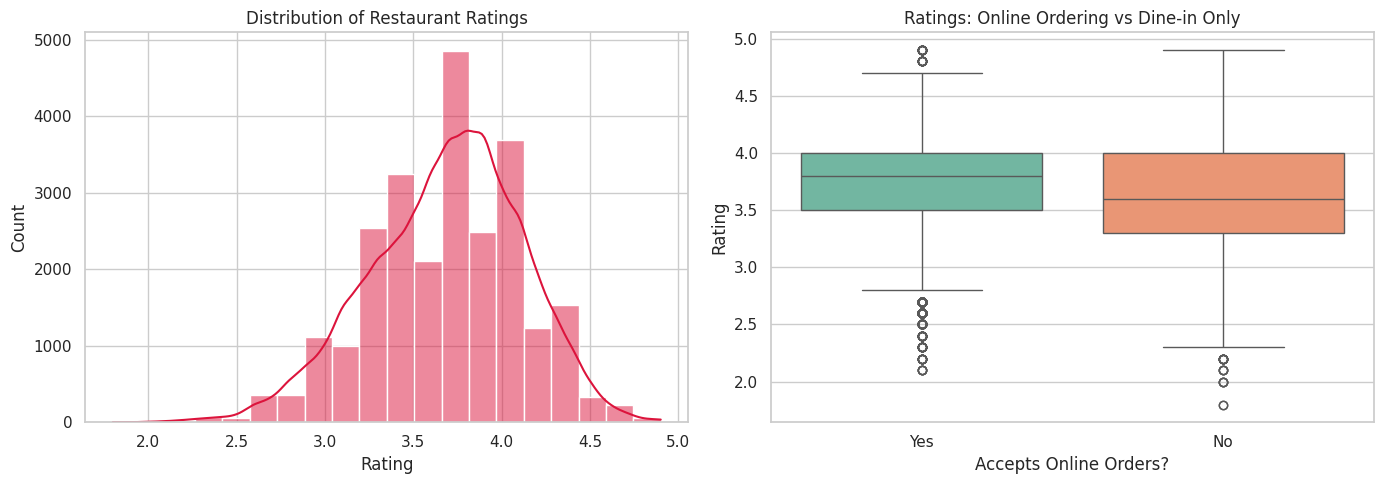

--- Quick Insights ---
Average Restaurant Rating in Bangalore: 3.69 / 5
Percentage of restaurants offering online ordering: 61.4%


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting environment style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Chart 1: Distribution of Restaurant Ratings
plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['rate'].dropna(), bins=20, kde=True, color='crimson')
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

# Chart 2: Online Order vs Ratings
plt.subplot(1, 2, 2)
sns.boxplot(x='online_order', y='rate', data=df_cleaned, palette='Set2')
plt.title('Ratings: Online Ordering vs Dine-in Only')
plt.xlabel('Accepts Online Orders?')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

# Print some quick, interesting insights
print("--- Quick Insights ---")
avg_rating = df_cleaned['rate'].mean()
print(f"Average Restaurant Rating in Bangalore: {avg_rating:.2f} / 5")

online_order_counts = df_cleaned['online_order'].value_counts(normalize=True) * 100
print(f"Percentage of restaurants offering online ordering: {online_order_counts.get('Yes', 0):.1f}%")


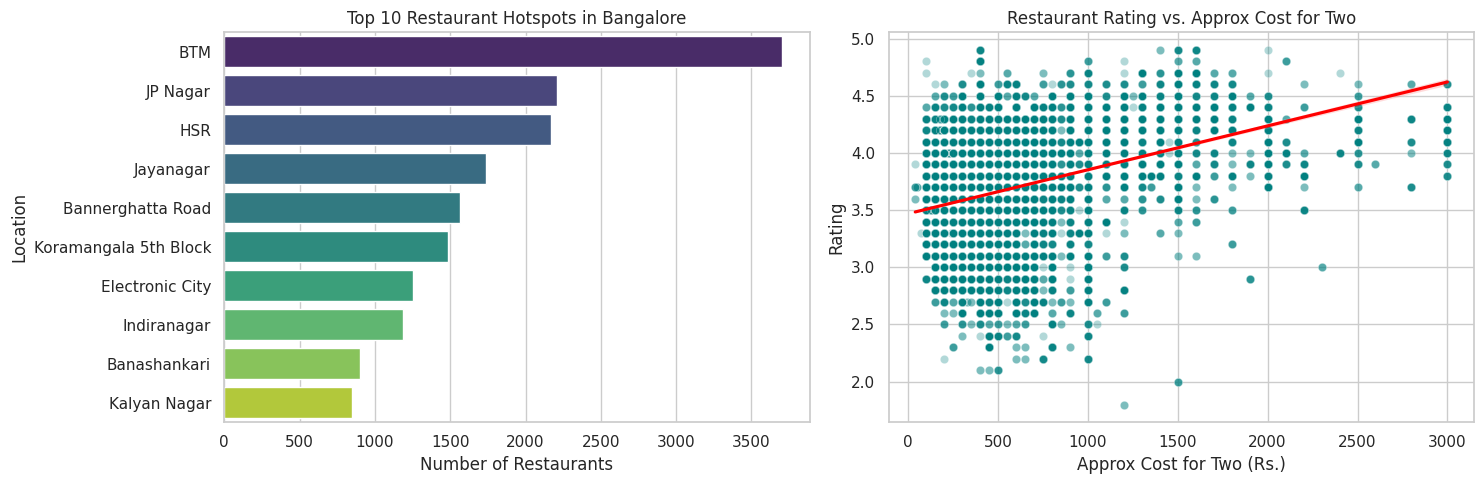

--- Top 3 Food Hubs ---
1. BTM: 3701 restaurants
2. JP Nagar: 2207 restaurants
3. HSR: 2169 restaurants


In [5]:
plt.figure(figsize=(15, 5))

# Chart 1: Top 10 Locations by Number of Restaurants
plt.subplot(1, 2, 1)
top_locations = df_cleaned['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, hue=top_locations.index, legend=False, palette='viridis')
plt.title('Top 10 Restaurant Hotspots in Bangalore')
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')

# Chart 2: Does Cost correlate with Rating?
plt.subplot(1, 2, 2)
# Filtering out extreme outliers in cost (> 3000) to keep the scatter plot readable
scatter_data = df_cleaned[df_cleaned['approx_cost_two'] <= 3000].dropna(subset=['rate', 'approx_cost_two'])
sns.scatterplot(x='approx_cost_two', y='rate', data=scatter_data, alpha=0.3, color='teal')
# Add a trend line to visually track if higher cost = higher rating
sns.regplot(x='approx_cost_two', y='rate', data=scatter_data, scatter=False, color='red')

plt.title('Restaurant Rating vs. Approx Cost for Two')
plt.xlabel('Approx Cost for Two (Rs.)')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

# Print location breakdown insights
print("--- Top 3 Food Hubs ---")
for i, (loc, count) in enumerate(top_locations.head(3).items(), 1):
    print(f"{i}. {loc}: {count} restaurants")

/tmp/ipykernel_9241/2043942838.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[count for _, count in top_cuisines], y=[cuis for cuis, _ in top_cuisines], palette='magma')
/tmp/ipykernel_9241/2043942838.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[count for _, count in top_dishes], y=[dish.title() for dish, _ in top_dishes], palette='plasma')


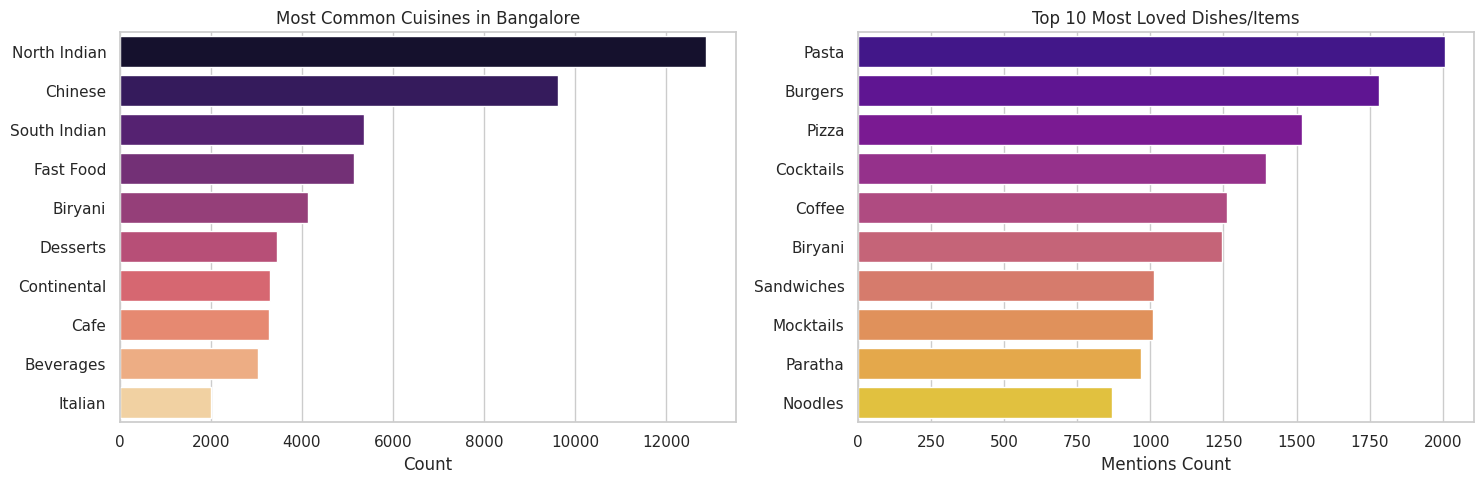

In [6]:
from collections import Counter

# 1. Top Cuisines Analysis
# Split the comma-separated cuisines and count them
cuisine_data = df_cleaned['cuisines'].dropna().str.split(', ')
all_cuisines = [cuisine for sublist in cuisine_data for cuisine in sublist]
top_cuisines = Counter(all_cuisines).most_common(10)

# 2. Top Discovered Dishes
# Split the comma-separated dishes that people liked
dish_data = df_cleaned['dish_liked'].dropna().str.split(', ')
all_dishes = [dish.strip().lower() for sublist in dish_data for dish in sublist]
top_dishes = Counter(all_dishes).most_common(10)

# Plotting the breakdowns
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=[count for _, count in top_cuisines], y=[cuis for cuis, _ in top_cuisines], palette='magma')
plt.title('Most Common Cuisines in Bangalore')
plt.xlabel('Count')

plt.subplot(1, 2, 2)
sns.barplot(x=[count for _, count in top_dishes], y=[dish.title() for dish, _ in top_dishes], palette='plasma')
plt.title('Top 10 Most Loved Dishes/Items')
plt.xlabel('Mentions Count')

plt.tight_layout()
plt.show()

## 📊 Restaurant Analytics Project: Core Findings & Conclusions

We performed an Exploratory Data Analysis on a dataset of over 31,000 restaurant entries to understand the competitive culinary landscape. Here are the strategic insights:

### 1. 📍 Market Hotspots & Competition
* **BTM Layout** is the absolute epicenter of food establishments in the region with 3,701 listed spots, closely followed by **JP Nagar** (2,207) and **HSR Layout** (2,169). Businesses opening here face immense competition but tap into massive local demand.

### 2. 🌐 Digital Adoption vs. Performance
* A significant **61.4%** of establishments leverage online ordering.
* Notably, restaurants supporting online ordering maintain higher median customer ratings and tighter quality consistency compared to exclusively dine-in operations.

### 3. 💰 Pricing Dynamics
* The average overall restaurant rating sits at **3.69 / 5**.
* There is a clear, positive correlation between cost and quality perception. While budget-friendly options display highly volatile ratings (ranging from poor to excellent), premium-tier establishments consistently secure upper-quartile ratings.

### 4. 🍕 The Supply vs. Demand Gap
* **Supply Side:** Restuarants heavily lean into offering **North Indian** and **Chinese** options, which saturate the market listings.
* **Demand Side (Customer Sentiment):** Text analysis of explicit user praise reveals that continental/fast food categories (**Pasta, Burgers, and Pizza**) generate the highest levels of customer engagement and positive reviews.